In [ ]:
# Deep learning models - MvTec Anamoly detection
# Anamoly type detection for category Transistor
# Predict anamoly type -  Bent-lead, Cut-lead, Damaged-case, Misplaced, Good
# Multi-CLass Classification

In [28]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization

# Importation pour la transformation sur les images
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.layers import Resizing
from tensorflow.keras.layers import RandomFlip
from tensorflow.keras.layers import RandomZoom
from tensorflow.keras.layers import RandomRotation
from tensorflow.keras.layers import RandomBrightness
from tensorflow.keras.layers import RandomContrast
from tensorflow.keras.layers import RandomTranslation 
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Importation de l'utilitaire image_dataset_from_directory de Keras
from keras.utils import image_dataset_from_directory
#from tensorflow.keras.applications import VGG16
#from tensorflow.keras.applications.vgg16 import preprocess_input
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import load_model
import tensorflow as tf
from tensorflow.keras import layers, models

# Importation pour les visualisations
import matplotlib.pyplot as plt
%matplotlib inline
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from imblearn.metrics import classification_report_imbalanced

from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from collections import Counter

In [7]:
df = pd.read_pickle("Data/mvtec_full_images_colour.pkl")
#df.shape
df.head()

,file_path,category_name,dir_name,file_name,file_size,label,img
0,..\Projects\mvtec_anomaly_detection\bottle\tes...,bottle,broken_large,000.png,526002,1,"[[[255, 255, 255], [255, 255, 255], [255, 255,..."
1,..\Projects\mvtec_anomaly_detection\bottle\tes...,bottle,broken_large,001.png,525657,1,"[[[255, 255, 255], [255, 255, 255], [255, 255,..."
2,..\Projects\mvtec_anomaly_detection\bottle\tes...,bottle,broken_large,002.png,515614,1,"[[[255, 255, 255], [255, 255, 255], [255, 255,..."
3,..\Projects\mvtec_anomaly_detection\bottle\tes...,bottle,broken_large,003.png,488569,1,"[[[255, 255, 255], [255, 255, 255], [255, 255,..."
4,..\Projects\mvtec_anomaly_detection\bottle\tes...,bottle,broken_large,004.png,549987,1,"[[[255, 255, 255], [255, 255, 255], [255, 255,..."


In [8]:
df_transistor = df[df["category_name"] == 'transistor']
display(df_transistor)

,file_path,category_name,dir_name,file_name,file_size,label,img
4317,..\Projects\mvtec_anomaly_detection\transistor...,transistor,bent_lead,000.png,1296700,1,"[[[133, 91, 86], [147, 102, 96], [148, 105, 97..."
4318,..\Projects\mvtec_anomaly_detection\transistor...,transistor,bent_lead,001.png,1285834,1,"[[[140, 97, 92], [141, 101, 93], [145, 102, 93..."
4319,..\Projects\mvtec_anomaly_detection\transistor...,transistor,bent_lead,002.png,1287496,1,"[[[147, 105, 92], [149, 103, 91], [135, 93, 86..."
4320,..\Projects\mvtec_anomaly_detection\transistor...,transistor,bent_lead,003.png,1274214,1,"[[[147, 101, 91], [147, 104, 91], [152, 104, 9..."
4321,..\Projects\mvtec_anomaly_detection\transistor...,transistor,bent_lead,004.png,1284517,1,"[[[162, 117, 108], [161, 117, 109], [161, 115,..."
...,...,...,...,...,...,...,...
4624,..\Projects\mvtec_anomaly_detection\transistor...,transistor,good,208.png,1274771,0,"[[[154, 106, 94], [157, 107, 95], [162, 109, 9..."
4625,..\Projects\mvtec_anomaly_detection\transistor...,transistor,good,209.png,1276350,0,"[[[146, 103, 90], [145, 103, 91], [151, 106, 9..."
4626,..\Projects\mvtec_anomaly_detection\transistor...,transistor,good,210.png,1282411,0,"[[[147, 103, 94], [148, 104, 91], [149, 105, 9..."
4627,..\Projects\mvtec_anomaly_detection\transistor...,transistor,good,211.png,1294543,0,"[[[151, 103, 89], [149, 103, 90], [150, 104, 8..."


In [9]:
# Get X and y
# Stack images
X = np.stack(df_transistor['img']).astype(np.float32)

# Preprocess for MobileNetV2
X = preprocess_input(X)

# Encode labels
le = LabelEncoder()
y = le.fit_transform(df_transistor['dir_name'])
class_names = le.classes_
num_classes = len(class_names)
print(class_names)
print(num_classes)

['bent_lead' 'cut_lead' 'damaged_case' 'good' 'misplaced']
5


In [17]:
# Data augmentation for minority classes
# Ananamoly types like Bent-lead, cut-lead have only 10 images each, so we should increase the anamoly images for good mdel predictions

from sklearn.utils import resample

X_balanced = []
y_balanced = []

target_count = 200

for cls, count in Counter(y).items():
    print(cls, count)
    X_cls = X[y == cls]
    y_cls = y[y == cls]

    if count < target_count:
        X_res, y_res = resample(
            X_cls, y_cls,
            replace=True,
            n_samples=target_count - count,
            random_state=42
        )
        X_cls = np.concatenate([X_cls, X_res])
        y_cls = np.concatenate([y_cls, y_res])

    X_balanced.append(X_cls)
    y_balanced.append(y_cls)

X_aug = np.concatenate(X_balanced)
y_aug = np.concatenate(y_balanced)





0 9
1 10
2 10
3 273
4 10


In [24]:
len(X_aug)
Counter(y_aug)

Counter({np.int64(3): 273,
         np.int64(0): 200,
         np.int64(1): 200,
         np.int64(2): 200,
         np.int64(4): 200})

In [21]:
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_aug),
    y=y_aug
)
class_weights = dict(enumerate(class_weights_array))
print("Class weights:", class_weights)

Class weights: {0: np.float64(1.073), 1: np.float64(1.073), 2: np.float64(1.073), 3: np.float64(0.7860805860805861), 4: np.float64(1.073)}


In [33]:
# Create MobileNetV2 model, compile and train
from sklearn.model_selection import train_test_split

# Split into train and validation
X_train, X_test, y_train, y_test = train_test_split(
    X_aug, y_aug,
    test_size=0.2,
    random_state=42,
    stratify=y_aug
)
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(256, 256, 3)
)
base_model.trainable = False  # CRUCIAL with small data
inputs = Input(shape=(256, 256, 3))

# Application des augmentations
x = RandomRotation(0.1)(inputs)                          
x = RandomTranslation(height_factor=0.1, width_factor=0.1)(x) 
x = RandomZoom(0.1)(x)  
x = RandomFlip("horizontal")(x)

x = base_model(x)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
outputs = Dense(5, activation="softmax")(x)

model = Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # use integer labels
    metrics=['accuracy']
)
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=32,callbacks = [reduce_learning_rate,
                                       early_stopping]
    #class_weight=class_weights
)

model.save('Models/model_predict_anamoly_MobileNet.keras')
#display_loss_accuracy_graph(history)
#display_evaluation_metrics(model)


C:\Users\kavit\AppData\Local\Temp\ipykernel_14624\4086624505.py:10: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Epoch 1/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 97s 3s/step - accuracy: 0.4977 - loss: 1.2334 - val_accuracy: 0.5860 - val_loss: 1.0694 - learning_rate: 0.0010
Epoch 2/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 80s 3s/step - accuracy: 0.7657 - loss: 0.6703 - val_accuracy: 0.5953 - val_loss: 0.9015 - learning_rate: 0.0010
Epoch 3/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 79s 3s/step - accuracy: 0.8322 - loss: 0.4871 - val_accuracy: 0.7023 - val_loss: 0.7407 - learning_rate: 0.0010
Epoch 4/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - accuracy: 0.8357 - loss: 0.4381 - val_accuracy: 0.7767 - val_loss: 0.6284 - learning_rate: 0.0010
Epoch 5/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 659s 3s/step - accuracy: 0.8834 - loss: 0.3559 - val_accuracy: 0.7767 - val_loss: 0.6074 - learning_rate: 0.0010
Epoch 6/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 79s 3s/step - accuracy: 0.9068 - loss: 0.2877 - val_accuracy: 0.6977 - val_loss: 0.7210 - learning_rate: 0.0010
Epoch 7/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 78s 3s/step - accuracy: 0.9033 - loss: 0.2702 - val_accuracy:

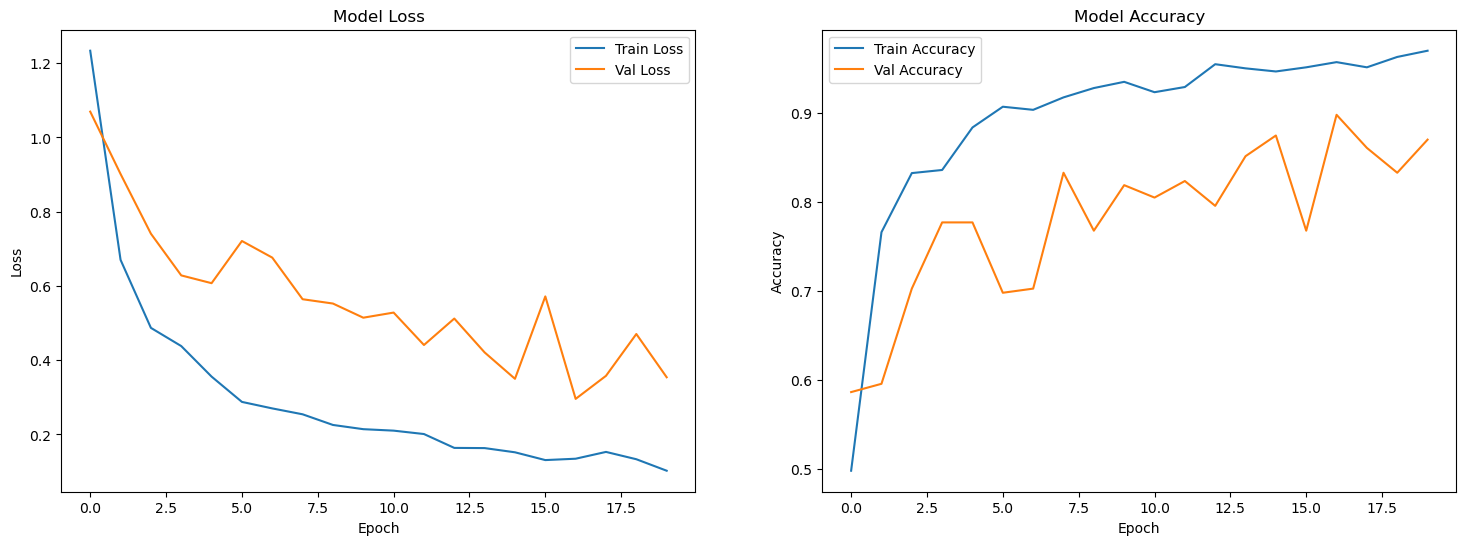

7/7 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step
Validation Accuracy: 0.8698


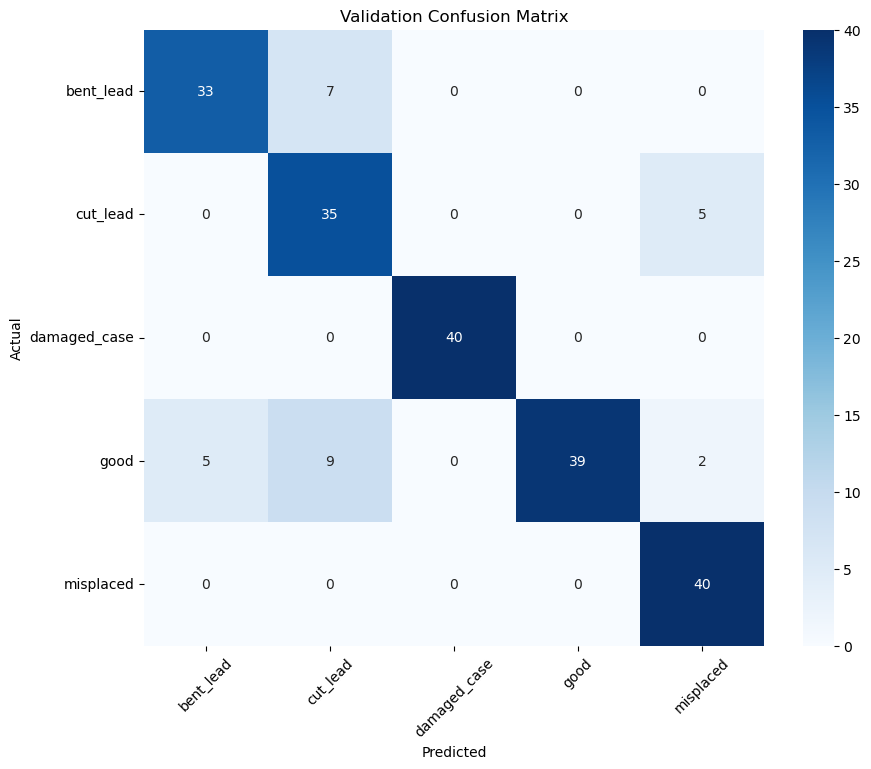

              precision    recall  f1-score   support

   bent_lead       0.87      0.82      0.85        40
    cut_lead       0.69      0.88      0.77        40
damaged_case       1.00      1.00      1.00        40
        good       1.00      0.71      0.83        55
   misplaced       0.85      1.00      0.92        40

    accuracy                           0.87       215
   macro avg       0.88      0.88      0.87       215
weighted avg       0.89      0.87      0.87       215

                    pre       rec       spe        f1       geo       iba       sup

   bent_lead       0.87      0.82      0.97      0.85      0.90      0.79        40
    cut_lead       0.69      0.88      0.91      0.77      0.89      0.79        40
damaged_case       1.00      1.00      1.00      1.00      1.00      1.00        40
        good       1.00      0.71      1.00      0.83      0.84      0.69        55
   misplaced       0.85      1.00      0.96      0.92      0.98      0.96        40

 avg 

In [36]:
loaded_model = load_model('Models/model_predict_anamoly_MobileNet.keras')
display_loss_accuracy_graph(history)
display_evaluation_metrics(model)

Notes: 
MobileNet - Predict transistor anamoly multi-class
7 bent-lead trated as cut-lead
5 cut-lead predicted as misplaced
Damaged case and Misplaced all well predicted
16 good are predicted as other class

Grad-CAM - Good sees only the leads
Damaged case sees whole transistor
Bent-lead and cut_lead are ok

In [130]:
# Grad-CAM
#img_path = "C:/Kavitha/DataScientest/Projects/mvtec_anomaly_detection/transistor/test/damaged_case/009.png"   # your image
img_path = "C:/Kavitha/DataScientest/Projects/mvtec_anomaly_detection/transistor/test/bent_lead/004.png" 
#img_path = "C:/Kavitha/DataScientest/Projects/mvtec_anomaly_detection/transistor/test/misplaced/005.png" 
#img_path = "C:/Kavitha/DataScientest/Projects/mvtec_anomaly_detection/transistor/test/damaged_case/009.png" 
#img_path = "C:/Kavitha/DataScientest/Projects/mvtec_anomaly_detection/transistor/test/good/001.png" 
#img_path = "C:/Kavitha/DataScientest/Projects/mvtec_anomaly_detection/transistor/train/good/001.png" 

# Load image
img = image.load_img(img_path, target_size=(256, 256))
img_array = image.img_to_array(img)

# Keep original for display
img_original = img_array.astype("uint8")

# Preprocess
img_array = preprocess_input(img_array)
img_array = np.expand_dims(img_array, axis=0)

# Get the nested MobileNetV2 model
# Get MobileNetV2 backbone
base_model = model.get_layer("mobilenetv2_1.00_224")
base_model.summary()
# Identify top layers
gap_layer = model.get_layer(index=-3)  # GlobalAveragePooling2D
dense_128 = model.get_layer(index=-2)  # Dense(128)
classifier_layer = model.get_layer(index=-1)  # Dense(nb_class)





Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)    │ (None, 256, 256, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 128, 128, 32)      │             864 │ input_layer_4[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 128, 128, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 128, 128, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 128, 128, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 128, 128, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 128, 128, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 128, 128, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 128, 128, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 128, 128, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 128, 128, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 128, 128, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 129, 129, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 64, 64, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [131]:

def make_gradcam_heatmap(img_array, base_model, gap_layer, classifier_layer, last_conv_layer_name="Conv_1", pred_index=None):
    """
    Generates Grad-CAM heatmap for a single image
    """

    # Build a model: input → last conv → classifier output
    grad_model = tf.keras.models.Model(
        inputs=base_model.input,
        outputs=[
            base_model.get_layer(last_conv_layer_name).output,
            classifier_layer(dense_128(gap_layer(base_model.output)))
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array, training=False)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    # Compute gradients
    grads = tape.gradient(class_channel, conv_outputs)

    # Global average pooling of gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weight the conv outputs
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize
    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + 1e-8

    return heatmap.numpy()


In [132]:
heatmap = make_gradcam_heatmap(
    img_array,
    base_model=base_model,
    gap_layer=gap_layer,
    classifier_layer=classifier_layer,
    last_conv_layer_name="Conv_1"  # MobileNetV2 last conv
)


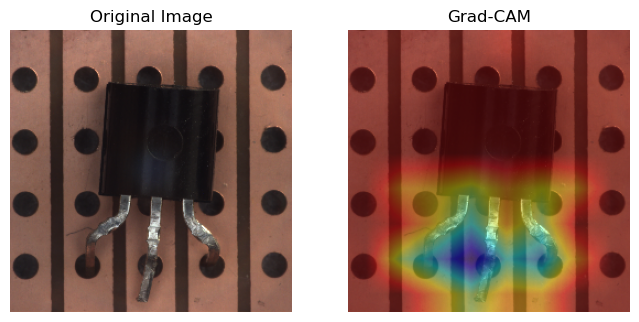

In [133]:
def overlay_gradcam(img, heatmap, alpha=0.4):
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    return cv2.addWeighted(img, 1 - alpha, heatmap, alpha, 0)

gradcam_img = overlay_gradcam(img_original, heatmap)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(img_original)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Grad-CAM")
plt.imshow(gradcam_img)
plt.axis("off")
plt.show()


In [138]:
import os
input_folder = "C:/Kavitha/DataScientest/Projects/mvtec_anomaly_detection/transistor/test/cut_lead/"  # replace with your folder
output_folder = "C:/Kavitha/DataScientest/Projects/gradcam_outputs/transistor/cut_lead/"
os.makedirs(output_folder, exist_ok=True)
def overlay_gradcam(img, heatmap, alpha=0.4):
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    return cv2.addWeighted(img, 1 - alpha, heatmap, alpha, 0)

def make_gradcam_heatmap(img_array, base_model, gap_layer, dense_layer, classifier_layer, last_conv_layer_name="Conv_1", pred_index=None):
    grad_model = tf.keras.models.Model(
        inputs=base_model.input,
        outputs=[
            base_model.get_layer(last_conv_layer_name).output,
            classifier_layer(dense_layer(gap_layer(base_model.output)))
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array, training=False)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + 1e-8
    return heatmap.numpy()
    
base_model = model.get_layer("mobilenetv2_1.00_224")
gap_layer = model.get_layer(index=-3)        # GlobalAveragePooling2D
dense_layer = model.get_layer(index=-2)      # Dense(128)
classifier_layer = model.get_layer(index=-1) # Dense(nb_class)

for filename in os.listdir(input_folder):
    if not filename.lower().endswith((".png", ".jpg", ".jpeg")):
        continue

    img_path = os.path.join(input_folder, filename)
    img = image.load_img(img_path, target_size=(256, 256))
    img_array = image.img_to_array(img)
    img_original = img_array.astype("uint8")
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    # Grad-CAM
    heatmap = make_gradcam_heatmap(
        img_array,
        base_model=base_model,
        gap_layer=gap_layer,
        dense_layer=dense_layer,
        classifier_layer=classifier_layer,
        last_conv_layer_name="Conv_1"
    )

    # Overlay
    gradcam_img = overlay_gradcam(img_original, heatmap)

    # Save
    save_path = os.path.join(output_folder, filename)
    cv2.imwrite(save_path, cv2.cvtColor(gradcam_img, cv2.COLOR_RGB2BGR))
    print(f"Saved Grad-CAM for {filename}")


Saved Grad-CAM for 000.png
Saved Grad-CAM for 001.png
Saved Grad-CAM for 002.png
Saved Grad-CAM for 003.png
Saved Grad-CAM for 004.png
Saved Grad-CAM for 005.png
Saved Grad-CAM for 006.png
Saved Grad-CAM for 007.png
Saved Grad-CAM for 008.png
Saved Grad-CAM for 009.png


In [30]:
early_stopping = EarlyStopping(
                                patience=3, # Attendre 5 epochs avant application
                                min_delta=0.01, # si au bout de 5 epochs la fonction de perte ne varie pas de 1%, 
    # que ce soit à la hausse ou à la baisse, on arrête
                                verbose=1, # Afficher à quel epoch on s'arrête
                                mode='min',
                                monitor='val_loss')

reduce_learning_rate = ReduceLROnPlateau(
                                    monitor="val_loss",
                                    patience=3, # si val_loss stagne sur 3 epochs consécutives selon la valeur min_delta
                                    min_delta=0.01,
                                    factor=0.1,  # On réduit le learning rate d'un facteur 0.1
                                    cooldown=4,  # On attend 4 epochs avant de réitérer 
                                    verbose=1)

In [31]:
def display_loss_accuracy_graph(model_history):
    train_loss = model_history.history["loss"]
    val_loss = model_history.history["val_loss"]
    train_acc = model_history.history["accuracy"]
    val_acc = model_history.history["val_accuracy"]

    plt.figure(figsize=(18,6))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(train_loss, label='Train Loss')
    plt.plot(val_loss, label='Val Loss')
    plt.title("Model Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(train_acc, label='Train Accuracy')
    plt.plot(val_acc, label='Val Accuracy')
    plt.title("Model Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.show()


In [32]:
def display_evaluation_metrics(model):
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    val_acc = accuracy_score(y_test, y_pred)
    print(f"Validation Accuracy: {val_acc:.4f}")
    
    val_cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10,8))
    sns.heatmap(val_cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Validation Confusion Matrix")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.show()
    
    print(classification_report(y_test, y_pred, target_names = class_names))
    print(classification_report_imbalanced(y_test, y_pred, target_names = class_names))


    print("True labels:", Counter(y_test))
    print("Predicted labels:", Counter(y_pred))
